### 4.4 SVAR: structural systems for both CPI measures

$$y_t = c + A_1y_{t-1} + A_2y_{t-2} + u_t,\quad u_t\sim(0,\Sigma)$$

$$\Sigma = PP',\qquad \varepsilon_t = P^{-1}u_t$$

$$\Theta_h = \Phi_h P$$

Two five-variable VAR(2)-in-levels systems (System A → `cpi_yoy`, System B →
`trimmed_mean_cpi_yoy`), recursive Cholesky ordering commodity growth → unemployment →
CPI target → business inflation expectations → cash rate, 80% contiguous block-bootstrap
IRF bands. **Read every panel below as illustrative, not causal.** Both systems still
reject multivariate residual whiteness and normality, verified live just below.

*Source: `src/models/svar.py`, exported to `reports/tableau/svar_irf.csv`*

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

import matplotlib.animation as animation
from IPython.display import Image, display

#### Residual diagnostics: verifying "illustrative, not causal"

Computed live below, from the same full-sample fits used throughout this section
(`fit_svar()`, pinned to the 2025Q4 forecast origin). The multivariate Portmanteau test
checks whether the five-equation residuals are still autocorrelated (whiteness); the
multivariate normality test checks whether they are jointly normally distributed. Both
reject at the 5% level for both systems, which is why every scenario built on these
systems ([§4.5](45_scenario_engine)) is labelled illustrative rather than causal.

The two tests aren't equally decisive, though. The chart below plots each test statistic
against its own 5% critical value on a log scale, since the raw p-values for normality
underflow to a displayed `0.0` (the true values are far below what a 64-bit float can
represent) and hide how close the whiteness result actually is. Whiteness clears its
threshold by a modest margin (roughly 1.2-1.4x); normality blows past its threshold by
two orders of magnitude.

*Source: `src/models/svar.py::svar_diagnostics`, computed live.*

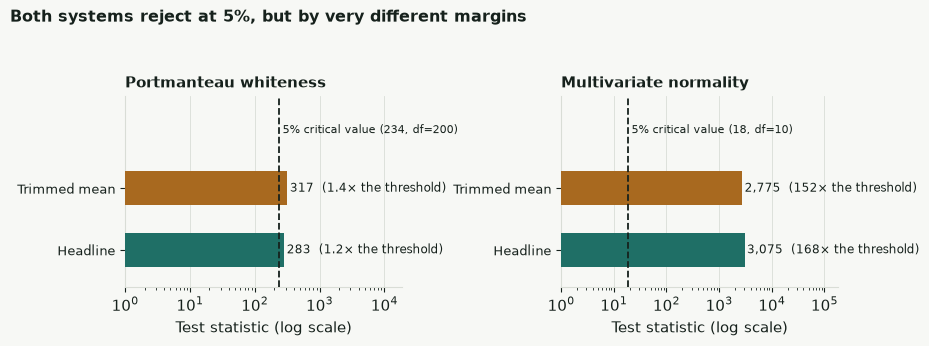

In [2]:
from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

rows = []
for system, config in SVAR_SYSTEMS.items():
    frame = svar.load_svar_level_frame(columns=config["columns"])
    frame = frame.loc[frame.index <= svar.FORECAST_ORIGIN_PIN]
    fitted = svar.fit_svar(frame, ordering=config["ordering"])
    mv = svar.svar_diagnostics(fitted).multivariate_tests.set_index("test")
    rows.append({
        "system": "Headline" if system == "System A" else "Trimmed mean",
        "whiteness_stat": mv.loc["portmanteau_whiteness", "statistic"],
        "whiteness_crit": mv.loc["portmanteau_whiteness", "critical_value"],
        "whiteness_df": mv.loc["portmanteau_whiteness", "df"],
        "normality_stat": mv.loc["multivariate_normality", "statistic"],
        "normality_crit": mv.loc["multivariate_normality", "critical_value"],
        "normality_df": mv.loc["multivariate_normality", "df"],
    })
diagnostics = pd.DataFrame(rows).set_index("system")
systems = diagnostics.index.tolist()
colors = {"Headline": ACCENT, "Trimmed mean": HIGHLIGHT}

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5))
for ax, (key, title) in zip(axes, [("whiteness", "Portmanteau whiteness"), ("normality", "Multivariate normality")]):
    stat, crit, df = diagnostics[f"{key}_stat"], diagnostics[f"{key}_crit"].iloc[0], int(diagnostics[f"{key}_df"].iloc[0])
    y = np.arange(len(systems))
    ax.barh(y, stat, color=[colors[s] for s in systems], height=0.55, zorder=3)
    ax.axvline(crit, color=INK, linewidth=1.3, linestyle="--", zorder=4)   # drawn above the bars
    ax.text(crit, len(systems) - 0.15, f" 5% critical value ({crit:.0f}, df={df})",
            fontsize=8, va="bottom", ha="left")
    for yi, s in zip(y, systems):
        val = stat[s]
        mult = val / crit
        mult_label = f"{mult:.1f}×" if mult < 10 else f"{mult:.0f}×"
        ax.text(val * 1.1, yi, f"{val:,.0f}  ({mult_label} the threshold)", va="center", fontsize=8.6)
    ax.set_xscale("log")
    ax.set_yticks(y, systems, fontsize=9.5)
    ax.set_xlim(1, stat.max() * 60)
    ax.set_ylim(-0.6, len(systems) + 0.5)
    ax.set_xlabel("Test statistic (log scale)")
    ax.set_title(title, loc="left", fontsize=10.8, fontweight="bold")
    ax.grid(axis="y", visible=False)
fig.suptitle("Both systems reject at 5%, but by very different margins", x=0.01, ha="left",
             fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

# The "illustrative, not causal" framing above and the scenario-engine caveat (src/models/scenario.py)
# both rest on this. If either statistic drops below its critical value, that prose needs updating.
assert (
    diagnostics[["whiteness_stat", "normality_stat"]].to_numpy()
    > diagnostics[["whiteness_crit", "normality_crit"]].to_numpy()
).all(), "a system's statistic no longer exceeds its 5% critical value"

**Reading it.** The two failures matter differently for what's built on top of these systems.
Whiteness clears its threshold by only 1.2-1.4x: there's some residual autocorrelation left in
a VAR(2), but not an overwhelming amount, so the IRF and historical-decomposition shapes
elsewhere in this section are unlikely to be wildly distorted by omitted dynamics. Normality
misses by two orders of magnitude, which would be a serious problem for any method that
assumes Gaussian errors. That's exactly why every IRF band in this section is the 80%
contiguous block-bootstrap mentioned in the intro above, not a normal-theory (delta-method)
interval: the block-bootstrap resamples the actual, non-normal residuals directly, so it
doesn't inherit this failure the way an analytic Gaussian interval would.

**Why levels, not differences.** Both systems are estimated in levels rather than first differences, a choice grounded in mixed unit-root evidence, not a clean stationarity
finding. The two charts below run ADF and KPSS live on all six variables across both systems,
in levels and after first-differencing; both tests agree on every variable except one. Running
both systems on levels keeps System A and System B directly comparable and preserves each
series' long-run relationships with the other four macro variables, at the cost of carrying
that one variable's undifferenced, borderline-unit-root behaviour into every IRF and
historical-decomposition panel below.

*Source: [Appendix §5: Stationarity Tests](../appendix_eda/05_stationarity_tests), [Appendix §15: Documented Limitations](../appendix_eda/15_documented_limitations)*

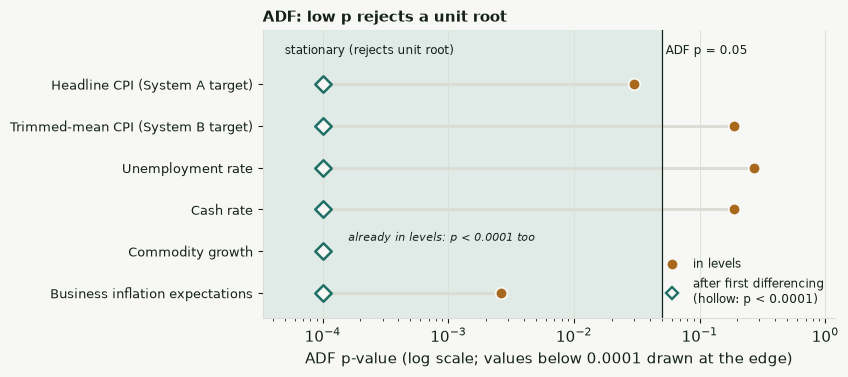

In [3]:
from statsmodels.tsa.stattools import adfuller
from matplotlib.lines import Line2D
from src.models import svar

df = pd.read_csv(CURATED)
df = df[df["quarter"] <= str(svar.FORECAST_ORIGIN_PIN)]
variables = [
    ("cpi_yoy", "Headline CPI (System A target)"),
    ("trimmed_mean_cpi_yoy", "Trimmed-mean CPI (System B target)"),
    ("unemployment_rate", "Unemployment rate"),
    ("cash_rate", "Cash rate"),
    ("commodity_growth", "Commodity growth"),
    ("inflation_expectations_business", "Business inflation expectations"),
]
rows = []
for col, label in variables:
    s = df[col].dropna()
    rows.append((label, adfuller(s, autolag="AIC")[1], adfuller(s.diff().dropna(), autolag="AIC")[1]))
res = pd.DataFrame(rows, columns=["label", "level", "diff1"]).iloc[::-1].reset_index(drop=True)
floor = 1e-4                                            # p-values below this are drawn at the floor
level_hit, diff_hit = res["level"] < floor, res["diff1"] < floor

fig, ax = plt.subplots(figsize=(8.6, 3.9))
ax.axvspan(floor / 3, 0.05, color=ACCENT, alpha=0.10, linewidth=0)
ax.axvline(0.05, color=INK, linewidth=0.9)
for y, r in res.iterrows():
    lo, hi = sorted([max(r["level"], floor), max(r["diff1"], floor)])
    ax.plot([lo, hi], [y, y], color=GRID, linewidth=2.2, zorder=1)
# level markers: skip rows whose level p-value is itself below the floor (annotated in text instead)
ax.scatter(res["level"][~level_hit], res.index[~level_hit], s=70, color=HIGHLIGHT, edgecolor=PAPER,
           linewidth=1.3, zorder=3)
# differenced markers: hollow when the true p-value is below the floor and only the position is clipped
ax.scatter(res["diff1"][diff_hit].clip(lower=floor), res.index[diff_hit], s=70, marker="D", facecolor=PAPER,
           edgecolor=ACCENT, linewidth=1.8, zorder=3)
ax.scatter(res["diff1"][~diff_hit], res.index[~diff_hit], s=70, marker="D", color=ACCENT, edgecolor=PAPER,
           linewidth=1.3, zorder=3)
for y in res.index[level_hit]:
    ax.text(floor * 1.6, y + 0.32, "already in levels: p < 0.0001 too", fontsize=8, va="center", style="italic")
ax.set_xscale("log")
ax.set_xlim(floor / 3, 1.2)
ax.set_yticks(res.index, res["label"], fontsize=9)
ax.text(0.05, len(res) - 0.35, " ADF p = 0.05", fontsize=8.5, va="bottom")
ax.text(floor / 2, len(res) - 0.35, "stationary (rejects unit root)", fontsize=8.5, va="bottom")
ax.set_ylim(-0.6, len(res) + 0.3)
ax.set_xlabel("ADF p-value (log scale; values below 0.0001 drawn at the edge)")
ax.set_title("ADF: low p rejects a unit root", loc="left", fontsize=11, fontweight="bold")
ax.legend(handles=[
    Line2D([], [], marker="o", linestyle="", markersize=8, markerfacecolor=HIGHLIGHT,
           markeredgecolor=PAPER, label="in levels"),
    Line2D([], [], marker="D", linestyle="", markersize=6, markerfacecolor=PAPER,
           markeredgecolor=ACCENT, markeredgewidth=1.7, label="after first differencing\n(hollow: p < 0.0001)"),
], frameon=False, fontsize=8.5, loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

The same six variables under KPSS, whose null hypothesis points the opposite way: it assumes
stationarity until the data pushes back hard enough to reject it. statsmodels only reports a
handful of table-interpolated p-values for KPSS, so this plots the underlying test statistic
against its own 5% critical value instead, which is continuous and not subject to that
table's clipping.

*Source: computed live from `data/curated/quarterly_macro_features.csv`.*

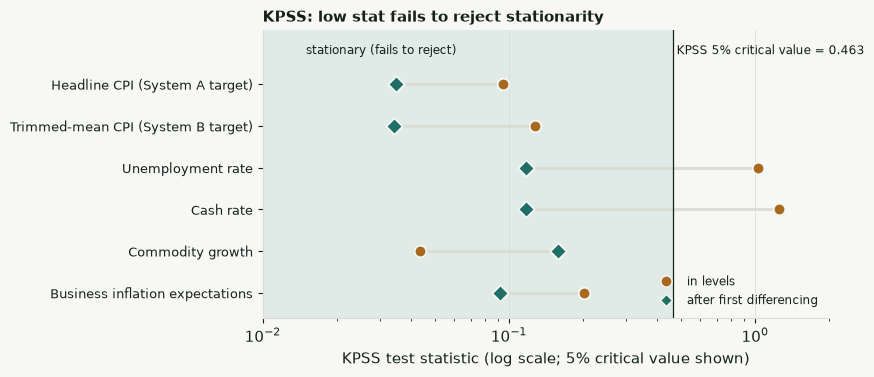

In [4]:
from statsmodels.tsa.stattools import kpss
from matplotlib.lines import Line2D
from src.models import svar

df = pd.read_csv(CURATED)
df = df[df["quarter"] <= str(svar.FORECAST_ORIGIN_PIN)]
variables = [
    ("cpi_yoy", "Headline CPI (System A target)"),
    ("trimmed_mean_cpi_yoy", "Trimmed-mean CPI (System B target)"),
    ("unemployment_rate", "Unemployment rate"),
    ("cash_rate", "Cash rate"),
    ("commodity_growth", "Commodity growth"),
    ("inflation_expectations_business", "Business inflation expectations"),
]
rows = []
kpss_crit5 = None
for col, label in variables:
    s = df[col].dropna()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # statsmodels warns when KPSS clips to its lookup table's edge
        kpss_level, _, _, crit = kpss(s, regression="c", nlags="auto")
        kpss_diff, _, _, _ = kpss(s.diff().dropna(), regression="c", nlags="auto")
    kpss_crit5 = kpss_crit5 or crit["5%"]
    rows.append((label, kpss_level, kpss_diff))
res = pd.DataFrame(rows, columns=["label", "level", "diff1"]).iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.6, 3.9))
ax.axvspan(1e-3, kpss_crit5, color=ACCENT, alpha=0.10, linewidth=0)
ax.axvline(kpss_crit5, color=INK, linewidth=0.9)
for y, r in res.iterrows():
    lo, hi = sorted([r["level"], r["diff1"]])
    ax.plot([lo, hi], [y, y], color=GRID, linewidth=2.2, zorder=1)
ax.scatter(res["level"], res.index, s=70, color=HIGHLIGHT, edgecolor=PAPER, linewidth=1.3, zorder=3)
ax.scatter(res["diff1"], res.index, s=70, marker="D", color=ACCENT, edgecolor=PAPER, linewidth=1.3, zorder=3)
ax.set_xscale("log")
ax.set_xlim(1e-2, 2)
ax.set_yticks(res.index, res["label"], fontsize=9)
ax.text(kpss_crit5, len(res) - 0.35, f" KPSS 5% critical value = {kpss_crit5:.3f}", fontsize=8.5, va="bottom")
ax.text(1.5e-2, len(res) - 0.35, "stationary (fails to reject)", fontsize=8.5, va="bottom")
ax.set_ylim(-0.6, len(res) + 0.3)
ax.set_xlabel("KPSS test statistic (log scale; 5% critical value shown)")
ax.set_title("KPSS: low stat fails to reject stationarity", loc="left", fontsize=11, fontweight="bold")
ax.legend(handles=[
    Line2D([], [], marker="o", linestyle="", markersize=8, markerfacecolor=HIGHLIGHT,
           markeredgecolor=PAPER, label="in levels"),
    Line2D([], [], marker="D", linestyle="", markersize=6, markerfacecolor=ACCENT,
           markeredgecolor=PAPER, label="after first differencing"),
], frameon=False, fontsize=8.5, loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Reading it.** Classify each variable by whether ADF (at level) rejects a unit root and
whether KPSS (at level) rejects stationarity, and five of the six variables get the same
verdict from both tests: `cpi_yoy`, `commodity_growth` and `inflation_expectations_business`
are stationary by both; `unemployment_rate` and `cash_rate` are non-stationary by both (their
KPSS statistics, 1.03 and 1.25, clear even the 1% critical value of 0.739, which is what long
stretches near a floor or ceiling followed by a sharp regime shift look like to a stationarity
test). `trimmed_mean_cpi_yoy` is the one exception: ADF fails to reject a unit root (p=0.19)
while KPSS's statistic (0.128) sits comfortably in the stationary region. That's not a
contradiction so much as low power in exactly the ambiguous middle both tests struggle with,
and it's precisely System B's target, which is why its borderline behaviour gets carried into
every later panel rather than resolved here.

#### Explained, step by step

- $y_t$ is a **vector** of five variables at once (commodity-price growth, unemployment, the CPI target, business inflation expectations, the cash rate), not a single series like SARIMA. $A_1, A_2$ are $5\times5$ matrices saying how *all five* variables at $t-1$ and $t-2$ feed into *all five* variables at $t$; $c$ is an intercept vector.
- $u_t$ is the vector of **reduced-form residuals**: the part of this quarter's movement the lagged history couldn't explain. $\Sigma$ is their covariance matrix. It captures that these five residuals are correlated *within* the same quarter (a bad quarter for commodity prices and a bad quarter for unemployment often coincide), but a plain VAR can't say which one "caused" the other.
- $\Sigma = PP'$ is a **Cholesky decomposition**: a lower-triangular matrix $P$ such that $PP'$ reconstructs $\Sigma$. $\varepsilon_t = P^{-1}u_t$ then converts the correlated residuals $u_t$ into new shocks $\varepsilon_t$ that are, by construction, uncorrelated with each other: genuinely independent, "structural" shocks.
- The catch, and the reason the app keeps warning "illustrative, not causal", is that this decomposition requires imposing an **ordering**: commodity growth $\to$ unemployment $\to$ CPI target $\to$ business inflation expectations $\to$ cash rate. This encodes an assumption that a commodity-price shock can move unemployment *within the same quarter*, but a same-quarter cash-rate shock cannot instantly move commodity prices. That's a judgment call the data doesn't prove, and a different, equally defensible ordering could shift the results. ([Appendix §12: Rolling Correlations / Relationship Stability](../appendix_eda/12_rolling_correlations) shows these cross-series relationships aren't fixed over the sample either, which is why a single static ordering is a simplification.)
- $\Theta_h = \Phi_h P$ is the **impulse response function (IRF)**: $\Phi_h$ (standard VAR theory) says how a shock to the *reduced-form* residuals propagates $h$ quarters forward, and multiplying by $P$ converts that into "how does one unit of *structural* shock $\varepsilon$ (e.g. an independent unemployment surprise) move the CPI target $h$ quarters later, holding every other variable's same-quarter shock fixed." That's what the IRF chart below plots.
- The historical decomposition below flips the IRF's question around: instead of "what would a hypothetical shock do," it asks "what did the shocks that actually happened do." It reuses the *same* $P$ and the *same* fitted VAR. It re-runs the model forward from its own initial conditions with every shock forced to zero (the *baseline*), then adds back each quarter's recovered structural shocks $\varepsilon_t$ one driver at a time. Because $u_t = P\varepsilon_t$ and the VAR is linear, baseline + all shock contributions reconstructs the actual path *exactly*, not approximately. It's bookkeeping on top of the same identified system, not a new model.
- **The structural shock is not the same as the plain forecast error.** The VAR's own single-equation residual $u_t$ and the structural shock $\varepsilon_t$ (after the $P^{-1}$ rotation) can differ in both size and sign, because the ordering lets earlier variables' *same-quarter* shocks spill into later ones. A quarter can show a small structural shock even when the raw single-equation miss was larger, if most of that miss is attributable to a contemporaneous shock elsewhere in the system. See the worked example below.

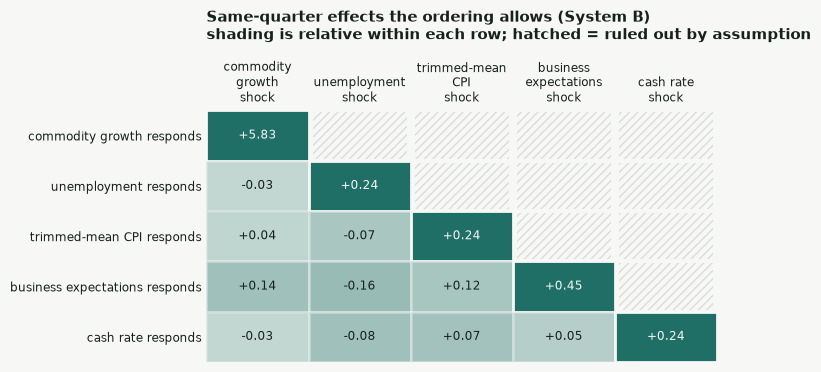

In [5]:
from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

config = SVAR_SYSTEMS["System B"]
frame = svar.load_svar_level_frame(columns=config["columns"])
frame = frame.loc[frame.index <= svar.FORECAST_ORIGIN_PIN]
fitted = svar.fit_svar(frame, ordering=config["ordering"])
names = [str(n) for n in fitted.names]                      # the recursive Cholesky order
P = np.asarray(fitted.irf(periods=1).P, dtype=float)        # P[i, j]: impact of shock j on variable i, same quarter
pretty = {"trimmed_mean_cpi_yoy": "trimmed-mean\nCPI", "inflation_expectations_business": "business\nexpectations",
          "unemployment_rate": "unemployment", "cash_rate": "cash rate", "commodity_growth": "commodity\ngrowth"}
labels = [pretty.get(n, n) for n in names]

fig, ax = plt.subplots(figsize=(7.4, 4.0))
n = len(names)
for i in range(n):
    for j in range(n):
        blocked = j > i
        rel = abs(P[i, j]) / np.abs(P[i]).max()          # shade within a row: rows are in different units
        if blocked:
            ax.add_patch(plt.Rectangle((j - 0.46, i - 0.46), 0.92, 0.92, fill=False, hatch="////",
                                       edgecolor=GRID, linewidth=0))
            continue
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=ACCENT, alpha=0.12 + 0.88 * rel,
                                   edgecolor=PAPER, linewidth=2))
        ax.text(j, i, f"{P[i, j]:+.2f}", ha="center", va="center", fontsize=8.5,
                color=PAPER if rel > 0.6 else INK)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.set_xticks(range(n), [f"{l}\nshock" for l in labels.copy()], fontsize=8.5)
ax.xaxis.tick_top()
ax.set_yticks(range(n), [f"{l.replace(chr(10), ' ')} responds" for l in labels], fontsize=8.5)
ax.grid(False)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Same-quarter effects the ordering allows (System B)\nshading is relative within each row; hatched = ruled out by assumption",
             loc="left", fontsize=10.5, fontweight="bold", y=1.25)
fig.tight_layout()
plt.show()

The same same-quarter picture for System A, the headline system:

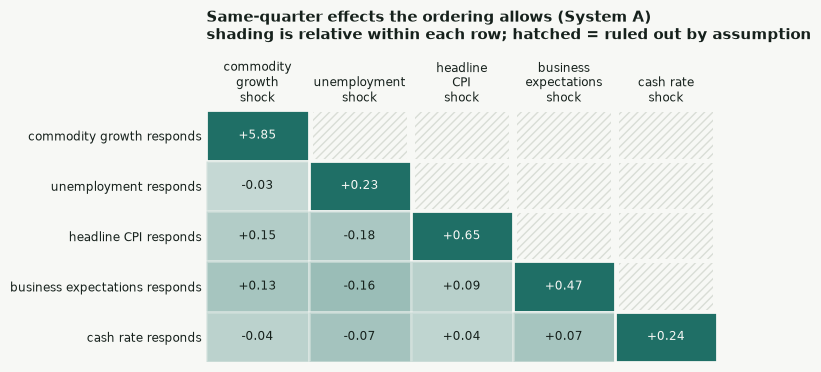

In [6]:
from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

config = SVAR_SYSTEMS["System A"]
frame = svar.load_svar_level_frame(columns=config["columns"])
frame = frame.loc[frame.index <= svar.FORECAST_ORIGIN_PIN]
fitted = svar.fit_svar(frame, ordering=config["ordering"])
names = [str(n) for n in fitted.names]                      # the recursive Cholesky order
P = np.asarray(fitted.irf(periods=1).P, dtype=float)        # P[i, j]: impact of shock j on variable i, same quarter
pretty = {"cpi_yoy": "headline\nCPI", "trimmed_mean_cpi_yoy": "trimmed-mean\nCPI", "inflation_expectations_business": "business\nexpectations",
          "unemployment_rate": "unemployment", "cash_rate": "cash rate", "commodity_growth": "commodity\ngrowth"}
labels = [pretty.get(n, n) for n in names]

fig, ax = plt.subplots(figsize=(7.4, 4.0))
n = len(names)
for i in range(n):
    for j in range(n):
        blocked = j > i
        rel = abs(P[i, j]) / np.abs(P[i]).max()          # shade within a row: rows are in different units
        if blocked:
            ax.add_patch(plt.Rectangle((j - 0.46, i - 0.46), 0.92, 0.92, fill=False, hatch="////",
                                       edgecolor=GRID, linewidth=0))
            continue
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=ACCENT, alpha=0.12 + 0.88 * rel,
                                   edgecolor=PAPER, linewidth=2))
        ax.text(j, i, f"{P[i, j]:+.2f}", ha="center", va="center", fontsize=8.5,
                color=PAPER if rel > 0.6 else INK)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.set_xticks(range(n), [f"{l}\nshock" for l in labels.copy()], fontsize=8.5)
ax.xaxis.tick_top()
ax.set_yticks(range(n), [f"{l.replace(chr(10), ' ')} responds" for l in labels], fontsize=8.5)
ax.grid(False)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Same-quarter effects the ordering allows (System A)\nshading is relative within each row; hatched = ruled out by assumption",
             loc="left", fontsize=10.5, fontweight="bold", y=1.25)
fig.tight_layout()
plt.show()

**Reading both matrices.** Focus on each system's target row (the middle row), since that's
what the rest of this section forecasts. Same-quarter, an unemployment shock pulls both CPI
measures down (-0.18pp headline, -0.07pp trimmed mean per one-SD shock) and a
commodity-growth shock pushes them up (+0.15pp headline, +0.04pp trimmed mean). Both signs
match the story the IRF and historical-decomposition panels below tell with more horizons
attached.

The bigger contrast is how much of each target's own move the ordering leaves unexplained by
the other four variables: headline's own-shock coefficient is +0.65, trimmed mean's is only
+0.24. That's expected, not a modelling inconsistency: trimmed mean is constructed
specifically to filter out the volatile items (fuel, fruit and vegetables) that drive a large
chunk of headline's idiosyncratic quarter-to-quarter noise, so more of its same-quarter
movement is explained by the four macro shocks and less is left over as an unexplained own
shock.

:::{dropdown} Why is commodity growth's own coefficient so large?
Commodity growth's own coefficient, +5.8 in both systems, looks enormous next to the rest of its row, but that's a units artifact, not a stronger effect. Commodity growth is a %-growth series with far more quarter-to-quarter variance than a CPI YoY rate, which is exactly why each row above is shaded relative to its own maximum rather than compared across rows.
:::

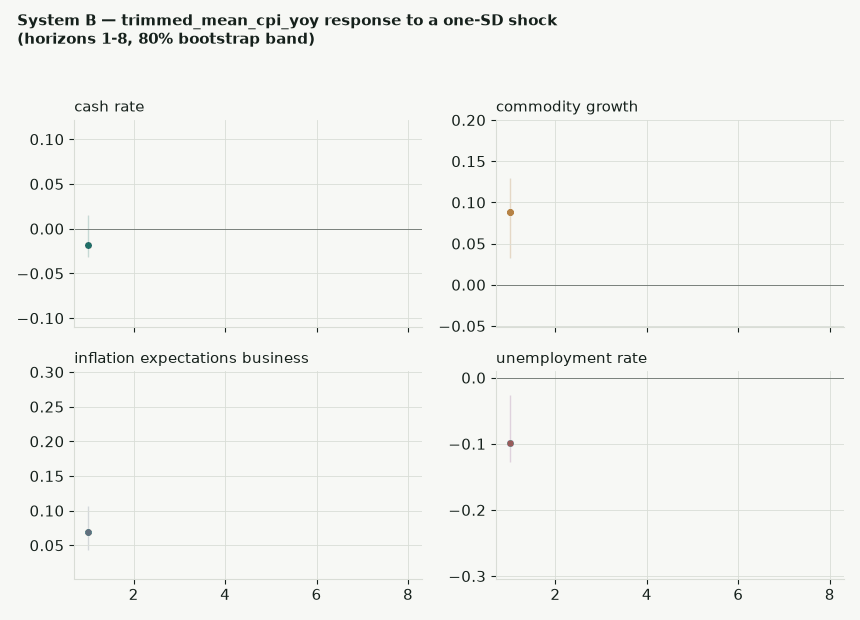

In [7]:
irf = pd.read_csv(PROJECT_ROOT / "reports/tableau/svar_irf.csv")
irf = irf[(irf["system"] == "System B") & (irf["response"] == "trimmed_mean_cpi_yoy")].copy()
shocks = sorted(irf["shock"].unique())
scolors = {shocks[0]: ACCENT, shocks[1]: HIGHLIGHT, shocks[2]: "#5b6f8f", shocks[3]: "#8a4f8a"}

fig, axes = plt.subplots(2, 2, figsize=(8.6, 6.2), sharex=True)
axes = axes.ravel()
lines, bands = [], []
for ax, shock in zip(axes, shocks):
    ax.axhline(0, color=INK, linewidth=0.7, alpha=0.5)
    ax.set_title(shock.replace("_", " "), fontsize=10.5, loc="left")
    ax.set_xlim(0.7, 8.3)
    sub = irf[irf["shock"] == shock].sort_values("horizon")
    pad = 0.15 * (sub["upper"].max() - sub["lower"].min())
    ax.set_ylim(sub["lower"].min() - pad, sub["upper"].max() + pad)
    bands.append(ax.fill_between([], [], [], color=scolors[shock], alpha=0.22))
    line, = ax.plot([], [], color=scolors[shock], linewidth=2.0, marker="o", markersize=4)
    lines.append(line)
fig.suptitle("System B — trimmed_mean_cpi_yoy response to a one-SD shock\n(horizons 1-8, 80% bootstrap band)",
             fontsize=10.8, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))

def update_irf(h):
    for i, shock in enumerate(shocks):
        sub = irf[irf["shock"] == shock].sort_values("horizon")
        sub = sub[sub["horizon"] <= h]
        lines[i].set_data(sub["horizon"], sub["irf"])
        bands[i].remove()
        bands[i] = axes[i].fill_between(sub["horizon"], sub["lower"], sub["upper"], color=scolors[shock], alpha=0.22)
    return lines

anim_irf = animation.FuncAnimation(fig, update_irf, frames=list(range(1, 9)) + [8] * 6, interval=350, blit=False)
gif_path = PROJECT_ROOT / "notebooks/assets/svar_animation.gif"
gif_path.parent.mkdir(parents=True, exist_ok=True)
anim_irf.save(gif_path, writer=animation.PillowWriter(fps=3))
plt.close(fig)
Image(filename=str(gif_path))

#### A caveat on the cash-rate channel: the "price puzzle"

In theory, a higher cash rate should pull inflation down. The cash-rate panel in the animation above doesn't really show that, and neither does System A's.

- **System A (headline).** After a one-SD cash-rate shock, headline CPI goes *up* for the first four quarters (+0.18pp at horizon 1, peaking at +0.24pp at horizon 3), and the 80% band stays above zero through horizon 4. From horizon 5 the band includes zero, and the response only turns negative at horizons 7 and 8.
- **System B (trimmed mean).** The response is tiny (within ±0.04pp at every horizon) and the 80% band straddles zero at all eight horizons, so it doesn't point either way.

System A's early rise is the well-documented **price puzzle**, a known quirk of small recursive VARs. The usual explanation is that the RBA tends to raise the cash rate *because* it already sees inflation building, and none of the five variables here picks that up. So the model reads the rate rise as pushing prices up. It's an identification artifact, not evidence that raising rates raises inflation, and it's why [§4.5](45_scenario_engine)'s cash-rate scenario effects shouldn't be read as a policy effect.

:::{dropdown} Show all four shock channels, both systems
{glue:}`/00_results_at_a_glance.ipynb::irf_channels_fig`

The same chart is on the [Key Findings](../00_results_at_a_glance) page, with the cash-rate panel annotated.
:::

*Source: `reports/tableau/svar_irf.csv` (`cash_rate` shock, own-target response, 80% bootstrap bands)*

#### Shock events: where the model flags unusual moves

`structural_shocks()` recovers each system's independent shocks from its own reduced-form
residuals; `svar_shock_events.csv` z-scores each system's own-target shock against its own
history and flags whichever quarters cross `|z| > 2`. Two systems, one shared threshold,
13 flagged quarters in total (5 for headline, 8 for trimmed mean): the GST introduction and its
2000-2001 base-effect unwind and the 2021 post-COVID inflation surge for headline; for trimmed
mean, 1999Q3 and 2000Q3 (the latter the GST quarter), the GFC-era spike (2007-2009) and
underlying-inflation persistence through 2022-2023's hiking cycle.

The GST and GFC flags are a sanity check: they land on episodes the model was never told about. The rest
fall inside the 2020-23 surge window shaded below, and that window is what the decomposition after this
section covers: trimmed mean flags 2021Q1, 2022Q4 and 2023Q4, and headline flags 2021Q2-3.

*Source: `src/models/svar.py::structural_shocks`, exported to
`reports/tableau/svar_shock_events.csv`*

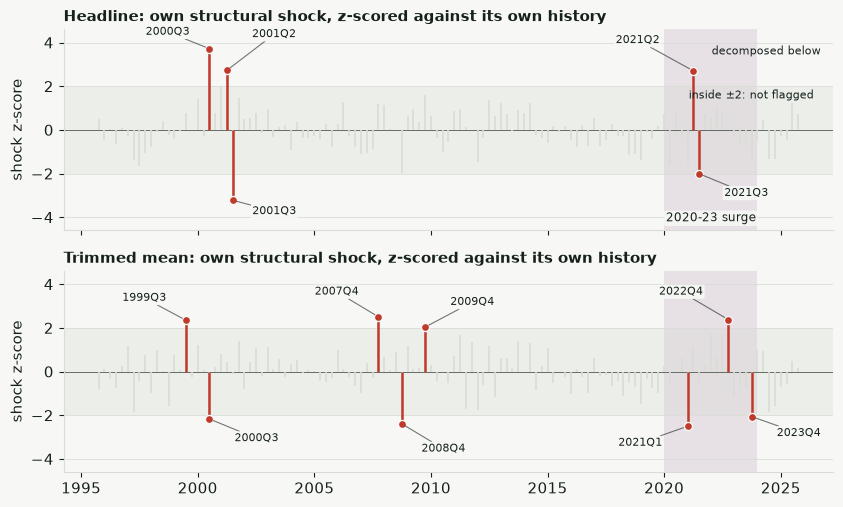

In [8]:
def shade_surge(ax, label=False, where="top", alpha=0.14):
    """The 2020-23 COVID and inflation-surge window as one light full-height band: one definition for the whole book.
    label=True names the band in plain text (do that once per figure); `where` is "top" or "bottom"."""
    s, e = pd.Period("2020Q1", "Q").to_timestamp(), pd.Period("2023Q4", "Q").to_timestamp(how="end")
    ax.axvspan(s, e, color="#8a4f8a", alpha=alpha, linewidth=0, zorder=0)
    if label:
        ax.text(s + (e - s) / 2, 0.97 if where == "top" else 0.03, "2020-23 surge", transform=ax.get_xaxis_transform(),
                ha="center", va="top" if where == "top" else "bottom", fontsize=8.5, color="#16211c", zorder=1.6,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="#f7f8f5", edgecolor="none", alpha=0.85))


def label_point(ax, x, y, text, offset, ha="center", size=7.8):
    """Quarter label with a thin leader line to the (already drawn) point at (x, y)."""
    ax.annotate(text, (x, y), xytext=offset, textcoords="offset points", ha=ha, va="center", fontsize=size, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=PAPER, edgecolor="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color=INK, alpha=0.6, linewidth=0.8, shrinkA=0, shrinkB=3))

# label offsets (points) for the flagged quarters, chosen to sit in empty space
OFFSETS = {
    ("System A", "2000Q3"): (-30, 12), ("System A", "2001Q2"): (34, 26), ("System A", "2001Q3"): (30, -8),
    ("System A", "2021Q2"): (-40, 22), ("System A", "2021Q3"): (34, -14),
    ("System B", "1999Q3"): (-30, 16), ("System B", "2000Q3"): (34, -14), ("System B", "2007Q4"): (-30, 18),
    ("System B", "2008Q4"): (30, -18), ("System B", "2009Q4"): (34, 18), ("System B", "2021Q1"): (-34, -12),
    ("System B", "2022Q4"): (-34, 20), ("System B", "2023Q4"): (34, -12),
}

events = pd.read_csv(TABLEAU / "svar_shock_events.csv")
events["date"] = pd.PeriodIndex(events["quarter"], freq="Q").to_timestamp()
SHOCK_COLOR = "#c0392b"

fig, axes = plt.subplots(2, 1, figsize=(8.6, 5.2), sharex=True)
for ax, (system, label) in zip(axes, [("System A", "Headline"), ("System B", "Trimmed mean")]):
    sub = events[events["system"] == system].sort_values("date")
    flagged = sub[sub["flagged"]]
    ax.axhspan(-2, 2, color=GRID, alpha=0.35, linewidth=0)
    ax.axhline(0, color=INK, linewidth=0.7, alpha=0.6)
    shade_surge(ax, label=(system == "System A"), where="bottom")
    ax.vlines(sub["date"], 0, sub["shock_z"], color=GRID, linewidth=1.2, zorder=2)
    ax.vlines(flagged["date"], 0, flagged["shock_z"], color=SHOCK_COLOR, linewidth=1.8, zorder=3)
    ax.scatter(flagged["date"], flagged["shock_z"], s=34, color=SHOCK_COLOR, edgecolor=PAPER, linewidth=1.0, zorder=4)
    for _, r in flagged.iterrows():
        label_point(ax, r["date"], r["shock_z"], r["quarter"], OFFSETS.get((system, r["quarter"]), (0, 22)))
    ax.set_ylim(-4.6, 4.6)
    ax.set_ylabel("shock z-score")
    ax.set_title(f"{label}: own structural shock, z-scored against its own history", loc="left",
                 fontsize=10.5, fontweight="bold")
    ax.grid(axis="x", visible=False)
axes[0].text(pd.Timestamp("2022-01-15"), 3.6, "decomposed below", ha="left", va="center", fontsize=8)
axes[0].text(pd.Timestamp("2026-06-01"), 1.85, "inside ±2: not flagged", fontsize=8, va="top", ha="right")
year_axis(axes[1], 5)
fig.tight_layout()
plt.show()

#### What a shock looks like on the series itself

A shock is defined as *actual minus the model's own prediction*, so it's worth seeing that
gap directly on the two series, not just as an abstract z-score in the chart above.

The dashed line below is each series with its own structural shock $\varepsilon_t$
subtracted out, quarter by quarter. This isn't a genuine out-of-sample forecast: it uses the same quarter's realizations of the other four structural shocks too, which a real forecast wouldn't have in advance. It's a **shock-neutral counterfactual**: what this
quarter's value would have been if only the target's *own* idiosyncratic surprise were
removed. The shaded gap between the two lines is exactly that shock, and the same flagged
quarters from the chart above are marked in red.

**Read the closeness with one more caveat: this is a full-sample, in-sample decomposition, not a walk-forward forecast.** `fit_svar()` is called *once*, on all 30 years of data (1995Q4-2025Q4), and that single fit is reused to compute the "implied" value for every historical quarter shown below, including 1996. A real 1996 forecaster never had the three decades of hindsight baked into these coefficients. Some of the closeness between the two lines is also just the series' own persistence (quarterly inflation moves slowly; any model with two of its own lags will track that), not evidence of the SVAR's forecasting skill. This is standard practice for *historical decomposition* in the SVAR literature (explaining what a model attributes the past to, not predicting the future), and it's a different exercise from this project's forecast-accuracy work (SARIMA / Elastic Net / Ensemble), which *is* walk-forward backtested. The fit also isn't uniformly close: the gap visibly widens at the GST era, the GFC, the COVID dip, and 2021-2023, exactly the flagged episodes.

*Source: computed live from the same fitted systems and `structural_shocks()` output used
throughout this section.*

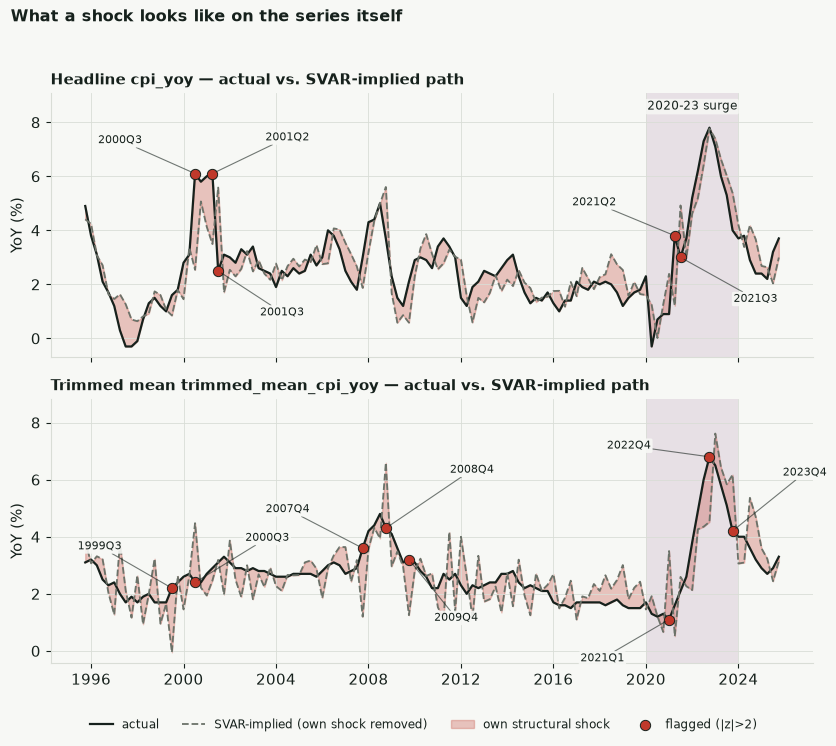

In [9]:
def shade_surge(ax, label=False, where="top", alpha=0.14):
    """The 2020-23 COVID and inflation-surge window as one light full-height band: one definition for the whole book.
    label=True names the band in plain text (do that once per figure); `where` is "top" or "bottom"."""
    s, e = pd.Period("2020Q1", "Q").to_timestamp(), pd.Period("2023Q4", "Q").to_timestamp(how="end")
    ax.axvspan(s, e, color="#8a4f8a", alpha=alpha, linewidth=0, zorder=0)
    if label:
        ax.text(s + (e - s) / 2, 0.97 if where == "top" else 0.03, "2020-23 surge", transform=ax.get_xaxis_transform(),
                ha="center", va="top" if where == "top" else "bottom", fontsize=8.5, color="#16211c", zorder=1.6,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="#f7f8f5", edgecolor="none", alpha=0.85))


def label_point(ax, x, y, text, offset, ha="center", size=8):
    """Quarter label with a thin leader line to the (already drawn) point at (x, y)."""
    ax.annotate(text, (x, y), xytext=offset, textcoords="offset points", ha=ha, va="center", fontsize=size, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=PAPER, edgecolor="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color=INK, alpha=0.6, linewidth=0.8, shrinkA=0, shrinkB=3))


from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

SHOCK_COLOR = "#c0392b"
IMPLIED_COLOR = "#6b7269"

panels = [("System A", "Headline"), ("System B", "Trimmed mean")]
# label offsets (points) for the flagged quarters, chosen to sit in empty space
OFFSETS = {
    ("System A", "2000Q3"): (-54, 24), ("System A", "2001Q2"): (54, 26), ("System A", "2001Q3"): (46, -30),
    ("System A", "2021Q2"): (-58, 24), ("System A", "2021Q3"): (54, -30),
    ("System B", "1999Q3"): (-52, 30), ("System B", "2000Q3"): (52, 32), ("System B", "2007Q4"): (-54, 28),
    ("System B", "2008Q4"): (62, 42), ("System B", "2009Q4"): (34, -42), ("System B", "2021Q1"): (-48, -28),
    ("System B", "2022Q4"): (-58, 8), ("System B", "2023Q4"): (52, 42),
}


fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.4), sharex=True)
for ax, (system, label) in zip(axes, panels):
    config = SVAR_SYSTEMS[system]
    target = config["target"]
    frame = svar.load_svar_level_frame(columns=config["columns"])
    frame = frame.loc[frame.index <= svar.FORECAST_ORIGIN_PIN]
    fitted = svar.fit_svar(frame, ordering=config["ordering"])

    shocks = svar.structural_shocks(fitted)
    own = shocks[shocks["shock"] == target].copy()
    own["date"] = pd.PeriodIndex(own["quarter"], freq="Q").to_timestamp()
    own = own.sort_values("date")

    actual = frame.loc[pd.PeriodIndex(own["quarter"], freq="Q"), target].to_numpy()
    implied = actual - own["shock_value"].to_numpy()
    std = own["shock_value"].std()
    z = own["shock_value"] / std
    flagged = z.abs() > 2

    shade_surge(ax, label=(system == "System A"), where="top")
    ax.plot(own["date"], actual, color=INK, linewidth=1.6, label="actual")
    ax.plot(own["date"], implied, color=IMPLIED_COLOR, linewidth=1.3, linestyle="--",
             label="SVAR-implied (own shock removed)")
    ax.fill_between(own["date"], actual, implied, color=SHOCK_COLOR, alpha=0.28,
                     label="own structural shock")
    ax.scatter(own.loc[flagged, "date"], actual[flagged.to_numpy()], s=55, color=SHOCK_COLOR,
               edgecolor=INK, linewidth=0.7, zorder=4, label="flagged (|z|>2)")
    for k in np.flatnonzero(flagged.to_numpy()):
        q = str(own["quarter"].iloc[k])
        label_point(ax, own["date"].iloc[k], actual[k], q, OFFSETS.get((system, q), (0, 24)))
    ax.set_title(f"{label} {target} — actual vs. SVAR-implied path", loc="left",
                 fontsize=10.8, fontweight="bold")
    ax.set_ylabel("YoY (%)")
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + (hi - lo) * 0.10)   # headroom so the surge label clears the 2022 peak

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=8.3, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("What a shock looks like on the series itself", fontsize=11.5, fontweight="bold",
             x=0.02, ha="left")
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
plt.show()

#### The 2020-23 surge, decomposed

`historical_decomposition()` splits each system's actual path into a zero-shock baseline
plus cumulative contributions from the four macro drivers and the target's own shock. By construction, baseline + Σ contributions reconstructs the actual path exactly (verified to
a maximum absolute error of ~1e-14 on this data).

The chart covers the same 2020Q1-2023Q4 window shaded above. Two things to keep in mind when reading it.
Each bar is a *cumulative* contribution, so a shock's effect lingers for several quarters and a bar isn't the
same thing as that quarter's flagged shock. And the model is still the single full-sample fit, so the bars
also carry the tail of shocks from before 2020: trimmed mean's own-shock bar starts the window at
-1.14pp, most of it carried in from earlier years, not a 2020 event.

**In short:** unemployment is the biggest drag in 2020, commodity prices and business inflation expectations drive the 2021 rebound, expectations then become the largest driver through 2022-23, and most of the 2023 fall is the own-shock bar unwinding. So the model can say the disinflation was faster than the macro drivers alone implied, but not which driver delivered it.

:::{dropdown} Period by period: the numbers behind the chart
- **2020, the COVID dip.** Headline falls to -0.3% in 2020Q2. Most of that comes from unemployment
  (-1.48pp, deepening to -1.83pp by 2020Q4) and the own shock (-0.67pp), with weak business inflation
  expectations adding another -0.57pp. Trimmed mean barely moves at first (still 1.3% in 2020Q2), but the
  unemployment drag builds every quarter, from -0.63pp to -1.22pp by **2021Q1**, where the own-shock bar
  also drops to -0.77pp and the quarter is flagged as the downside surprise (z = -2.51).
- **2021, the rebound.** **2021Q2** brings a sharp own-shock jump in headline inflation (bar at +1.04pp,
  z = +2.70) as commodity-price growth (+0.65pp) and business inflation expectations (+0.26pp) outweigh a
  fading unemployment drag (-0.94pp, down from -1.83pp two quarters earlier). Headline reaches 3.8%. In
  **2021Q3** the own shock partly reverses (bar at -0.37pp, z = -2.01) while commodity growth and expectations
  stay the main positive forces.
- **2022-23, the surge and the turn.** Headline peaks at 7.8% and trimmed mean at 6.8%, both in 2022Q4.
  Unemployment flips from a drag to a push (headline +1.11pp by 2022Q3), and business inflation
  expectations become the largest driver: +2.10pp for headline in 2022Q4, still +1.46pp in 2023Q4. For
  trimmed mean the own-shock bar climbs from -0.20pp in 2021Q4 to +1.95pp in **2022Q4** (z = +2.38), then
  unwinds to +0.07pp by **2023Q4** (z = -2.06).
- **What the 2023 fall came from.** From the 2022Q4 peak to 2023Q4, headline drops 3.8pp and about 2.5pp
  of that is its own-shock bar unwinding (+1.15pp to -1.40pp). For trimmed mean the same bar accounts for
  1.9pp of a 2.6pp fall. No named driver turned strongly negative, so the model can say the disinflation
  was faster than the macro drivers alone implied, but not which driver delivered it.
:::

The cash-rate bars flip sign in headline's panel (mostly negative through 2022Q3, positive from 2022Q4), but given
the price puzzle above they shouldn't be read as the RBA's hikes lowering or raising inflation.

**Read this with the same caveat as the IRF panels above.** Attributing a specific
quarter's move to a named driver rests on the same recursive Cholesky ordering, so it's a
*stronger* identification claim than a hypothetical IRF chart, not a weaker one.

*Source: `src/models/svar.py::historical_decomposition`, exported to
`reports/tableau/svar_historical_decomposition.csv`*

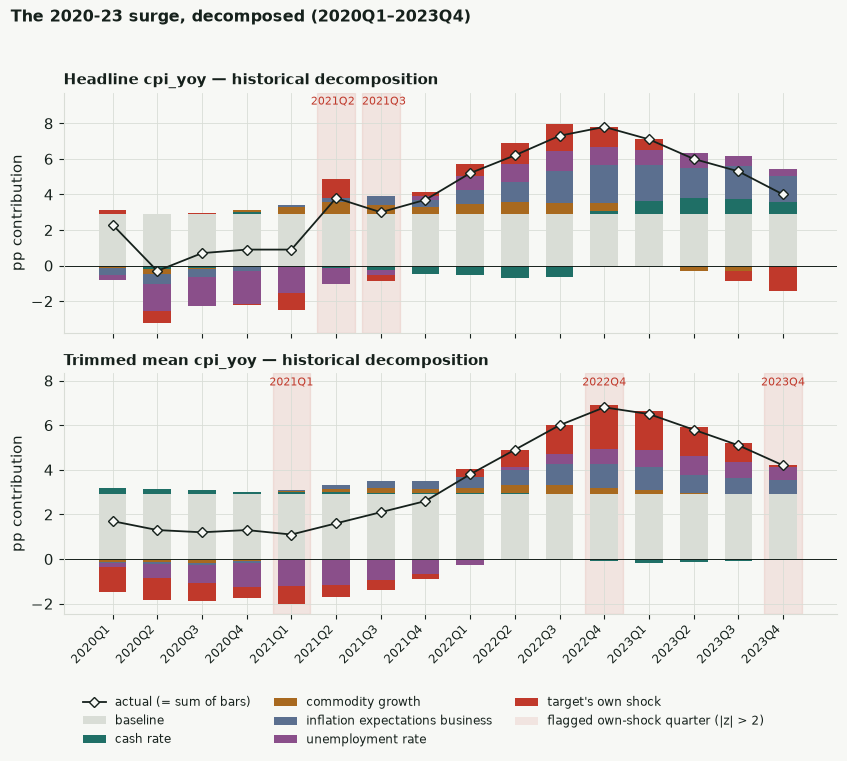

In [10]:
def label_point(ax, x, y, text, offset, ha="center", size=8):
    """Quarter label with a thin leader line to the (already drawn) point at (x, y)."""
    ax.annotate(text, (x, y), xytext=offset, textcoords="offset points", ha=ha, va="center", fontsize=size, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=PAPER, edgecolor="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color=INK, alpha=0.6, linewidth=0.8, shrinkA=0, shrinkB=3))


from matplotlib.patches import Patch

SURGE = ("2020Q1", "2023Q4")   # the one surge window used across the book
hd = pd.read_csv(PROJECT_ROOT / "reports/tableau/svar_historical_decomposition.csv")
window = hd[(hd["quarter"] >= SURGE[0]) & (hd["quarter"] <= SURGE[1])].copy()
shock_events = pd.read_csv(TABLEAU / "svar_shock_events.csv")

driver_colors = {
    "cash_rate": ACCENT,
    "commodity_growth": HIGHLIGHT,
    "inflation_expectations_business": "#5b6f8f",
    "unemployment_rate": "#8a4f8a",
}
OWN_SHOCK_COLOR = "#c0392b"
BASELINE_COLOR = GRID

panels = [
    ("System A", "cpi_yoy", "Headline cpi_yoy"),
    ("System B", "trimmed_mean_cpi_yoy", "Trimmed mean cpi_yoy"),
]

fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.4), sharex=True)
for ax, (system, target_col, label) in zip(axes, panels):
    sub = window[window["system"] == system]
    piv = sub.pivot_table(index="quarter", columns="component", values="contribution")
    piv = piv.reindex(sorted(piv.index, key=lambda q: pd.Period(q, freq="Q")))
    x = np.arange(len(piv))

    flagged_quarters = shock_events[(shock_events["system"] == system) & shock_events["flagged"]
                                    & shock_events["quarter"].isin(piv.index)]["quarter"]
    flagged_x = sorted(list(piv.index).index(fq) for fq in flagged_quarters)
    for xi in flagged_x:
        ax.axvspan(xi - 0.42, xi + 0.42, color=OWN_SHOCK_COLOR, alpha=0.10, zorder=0)

    order = ["baseline"] + list(driver_colors.keys()) + [target_col]
    bottom_pos = np.zeros(len(piv))
    bottom_neg = np.zeros(len(piv))
    for comp in order:
        vals = piv[comp].to_numpy()
        color = BASELINE_COLOR if comp == "baseline" else (
            OWN_SHOCK_COLOR if comp == target_col else driver_colors[comp]
        )
        comp_label = "target's own shock" if comp == target_col else comp.replace("_", " ")
        pos = np.where(vals > 0, vals, 0.0)
        neg = np.where(vals < 0, vals, 0.0)
        ax.bar(x, pos, bottom=bottom_pos, color=color, width=0.62, label=comp_label,
               zorder=2)
        ax.bar(x, neg, bottom=bottom_neg, color=color, width=0.62, zorder=2)
        bottom_pos += pos
        bottom_neg += neg

    actual = piv.sum(axis=1)
    ax.plot(x, actual, color=INK, marker="D", markersize=5, markerfacecolor=PAPER,
             markeredgecolor=INK, linewidth=1.3, label="actual (= sum of bars)", zorder=3)
    ax.axhline(0, color=INK, linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, fontsize=8.5, rotation=45, ha="right")
    ax.set_ylabel("pp contribution")
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + (hi - lo) * 0.10)   # headroom for the flagged-quarter labels
    top = ax.get_ylim()[1]
    for xi in flagged_x:
        # adjacent flagged quarters: the first label hangs left of its column, the second hangs right of its own
        left, right = (xi + 1) in flagged_x, (xi - 1) in flagged_x
        ha, tx = ("right", xi + 0.42) if left else (("left", xi - 0.42) if right else ("center", xi))
        ax.text(tx, top - (top - lo) * 0.015, piv.index[xi], ha=ha, va="top", fontsize=8, color=OWN_SHOCK_COLOR, zorder=6)
    ax.set_title(f"{label} — historical decomposition", loc="left", fontsize=10.5, fontweight="bold")

handles, labels_ = axes[0].get_legend_handles_labels()
handles.append(Patch(facecolor=OWN_SHOCK_COLOR, alpha=0.10))
labels_.append("flagged own-shock quarter (|z| > 2)")
fig.legend(handles, labels_, loc="lower center", ncol=3, fontsize=8.3, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("The 2020-23 surge, decomposed (2020Q1–2023Q4)",
             fontsize=11.5, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0.07, 1, 0.96))
plt.show()


#### A caveat: a record level isn't always a shock

Both series hit their all-time high in the *same* quarter: headline at 7.8%, trimmed mean
at 6.8%, both 2022Q4, both records since 1995. Only one of them is flagged as a shock.

The chart below shows why, computed live from the same two fitted systems used throughout
this section. Headline's raw single-equation residual that quarter was actually -0.057pp
(the plain VAR *slightly over-predicted*, at 7.857%), but the Cholesky rotation
attributes most of that miss to commodity-growth's and unemployment's own same-quarter
shocks (which the ordering lets move CPI contemporaneously), leaving only +0.037pp
uniquely attributable to headline's own equation. Trimmed mean's structural shock that
same quarter is +2.28pp, genuinely large, and flagged.

**A record level and a shock are different questions, and this quarter shows they don't
always agree**: a sustained climb to an all-time high can be almost entirely priced in by
the model's own dynamics (headline's case), or it can still contain a genuine,
model-surprising jump on top of the climb (trimmed mean's case).

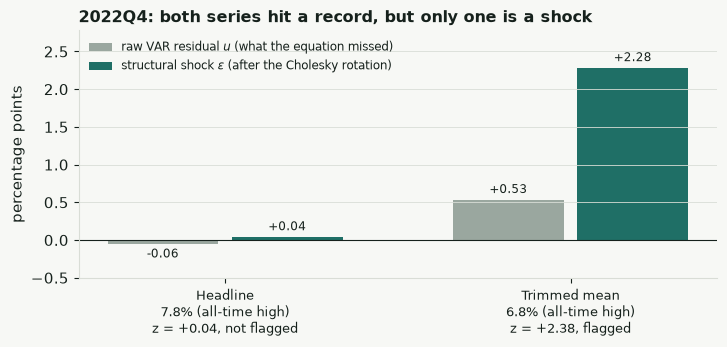

In [11]:
from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

CAVEAT_QUARTER = pd.Period("2022Q4", freq="Q")

rows = []
for system, config in SVAR_SYSTEMS.items():
    target = config["target"]
    sys_frame = svar.load_svar_level_frame(columns=config["columns"])
    sys_frame = sys_frame.loc[sys_frame.index <= svar.FORECAST_ORIGIN_PIN]
    fitted = svar.fit_svar(sys_frame, ordering=config["ordering"])

    actual = sys_frame.loc[CAVEAT_QUARTER, target]
    u = fitted.resid.loc[CAVEAT_QUARTER, target]

    shocks = svar.structural_shocks(fitted)
    own = shocks[shocks["shock"] == target].set_index("quarter")
    eps = own.loc[str(CAVEAT_QUARTER), "shock_value"]
    std = own["shock_value"].std()

    rows.append({
        "system": "Headline" if system == "System A" else "Trimmed mean",
        "level": actual,
        "record": actual == sys_frame[target].max(),
        "u": u, "eps": eps, "z": eps / std, "flagged": bool(abs(eps / std) > 2),
    })
caveat = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.4, 3.6))
x = np.arange(len(caveat))
w = 0.32
b1 = ax.bar(x - w / 2 - 0.02, caveat["u"], w, color=MUTED, label="raw VAR residual $u$ (what the equation missed)")
b2 = ax.bar(x + w / 2 + 0.02, caveat["eps"], w, color=ACCENT, label=r"structural shock $\varepsilon$ (after the Cholesky rotation)")
ax.axhline(0, color=INK, linewidth=0.8)
for bars, col in ((b1, "u"), (b2, "eps")):
    for rect, v in zip(bars, caveat[col]):
        ax.annotate(f"{v:+.2f}", (rect.get_x() + rect.get_width() / 2, v), xytext=(0, 3 if v >= 0 else -3),
                    textcoords="offset points", ha="center", va="bottom" if v >= 0 else "top", fontsize=8.5)
labels = [f"{r.system}\n{r.level:.1f}% (all-time high)\nz = {r.z:+.2f}, " + ("flagged" if r.flagged else "not flagged")
          for r in caveat.itertuples()]
ax.set_xticks(x, labels, fontsize=9)
ax.set_ylim(min(caveat[["u", "eps"]].min().min() - 0.4, -0.5), caveat[["u", "eps"]].max().max() + 0.5)
ax.set_ylabel("percentage points")
ax.set_title("2022Q4: both series hit a record, but only one is a shock", loc="left", fontsize=11.5, fontweight="bold")
ax.legend(frameon=False, fontsize=8.3, loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()